In [1]:
# Install required packages
!pip install -q diffusers transformers peft accelerate lpips

print("✓ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.3 MB/s eta 0:00:00
✓ Dependencies installed


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image
from diffusers import (
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    UniPCMultistepScheduler,
    UNet2DConditionModel
)
from transformers import CLIPProcessor, CLIPModel
from peft import PeftModel
import lpips as lpips_module
import cv2
import matplotlib.pyplot as plt
from google.colab import files, drive

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
# Paths - UPDATE THESE if your paths are different
MODEL_PATH = "/content/drive/MyDrive/CIS_5190_Project_Material/Models/sd-v1-5"
CONTROLNET_CANNY_PATH = "/content/drive/MyDrive/CIS_5190_Project_Material/Models/controlnet-canny"
CONTROLNET_DEPTH_PATH = "/content/drive/MyDrive/CIS_5190_Project_Material/Models/controlnet-depth"

LORA_CHECKPOINT = "/content/drive/MyDrive/CIS_5190_Project_Material/LoRA_Checkpoints(D+C)/lora_epoch_5"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16

lpips_fn = lpips_module.LPIPS(net='alex').to(device)
lpips_fn.eval()
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()



Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 218MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [5]:
# 1. Use the official Hugging Face repository IDs instead of local paths
HF_CANNY_ID = "lllyasviel/sd-controlnet-canny"
HF_DEPTH_ID = "lllyasviel/sd-controlnet-depth"
HF_SD_ID = "runwayml/stable-diffusion-v1-5"

print("Downloading ControlNet-Canny from Hugging Face...")
controlnet_canny = ControlNetModel.from_pretrained(
    HF_CANNY_ID,
    torch_dtype=dtype
    # Removed local_files_only=True!
).to(device)

print("Downloading ControlNet-Depth from Hugging Face...")
controlnet_depth = ControlNetModel.from_pretrained(
    HF_DEPTH_ID,
    torch_dtype=dtype
    # Removed local_files_only=True!
).to(device)

print("Downloading UNet from Hugging Face...")
unet = UNet2DConditionModel.from_pretrained(
    HF_SD_ID,
    subfolder="unet",
    torch_dtype=dtype
    # Removed local_files_only=True!
).to(device)

import os
from google.colab import drive

# 1. Force Colab to refresh its Drive connection
drive.mount('/content/drive', force_remount=True)

# 2. Tell Colab to explicitly look inside that folder to wake up the cache
lora_path = "/content/drive/MyDrive/CIS_5190_Project_Material/LoRA_Checkpoints(D+C)/lora_epoch_5"

if os.path.exists(lora_path):
    print("Folder found! Contents:")
    print(os.listdir(lora_path))
else:
    print("Colab STILL can't see the folder.")

print("Applying custom LoRA weights from Google Drive...")
# 2. YOUR LORA MUST STAY LOCAL!
# Hugging Face doesn't have this file because you just made it.
unet = PeftModel.from_pretrained(
    unet,
    LORA_CHECKPOINT,      # This should still be your /content/drive/... path
    local_files_only=True # Keep this so it knows to look in your Drive!
)

Mounted at /content/drive
Folder found! Contents:
['README.md', 'adapter_model.safetensors', 'adapter_config.json']
Applying custom LoRA weights from Google Drive...


In [33]:
def compute_canny_edges(image, low_threshold=40, high_threshold=260):
    """
    Compute Canny edges from PIL Image.

    Args:
        image: PIL Image (RGB)
        low_threshold: Canny low threshold
        high_threshold: Canny high threshold

    Returns:
        PIL Image of Canny edges (3-channel RGB)
    """
    # Convert to grayscale numpy array
    img_gray = np.array(image.convert('L'))
    brightness = np.mean(img_gray)

    if (brightness < 70):
        #Its likely a night image
        low_threshold, high_threshold = 50, 100

      # Apply Gaussian blur
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Detect edges
    edges = cv2.Canny(img_blur, low_threshold, high_threshold)

    # Convert to 3-channel RGB
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

    return Image.fromarray(edges_rgb)

In [7]:
import torch
from transformers import pipeline, logging
from PIL import Image

logging.set_verbosity_error()

depth_estimator = pipeline(
    'depth-estimation',
    model='Intel/dpt-large',
    device=0
)

def depthMaps(image):
    predictions = depth_estimator(image)
    depth_map = predictions['depth']

    return depth_map

config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

In [34]:
def compute_lpips(generated_img, target_img):
    """
    Compute LPIPS perceptual distance between two images.

    Args:
        generated_img: PIL Image
        target_img: PIL Image

    Returns:
        float: LPIPS distance (lower is better)
    """
    # Resize target to match generated
    generated_img = generated_img.convert("RGB")
    target_resized = target_img.convert("RGB").resize(generated_img.size, Image.BILINEAR)

    # Convert to tensors normalized to [-1, 1] - For Richard Zhang's LPIPS library
    def to_tensor(img):
        img_np = np.array(img).astype(np.float32) / 127.5 - 1
        return torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

    gen_tensor = to_tensor(generated_img)
    tgt_tensor = to_tensor(target_resized)

    # Compute LPIPS
    with torch.no_grad():
        distance = lpips_fn(gen_tensor, tgt_tensor).item()

    return distance


print("✓ LPIPS computation function defined")

✓ LPIPS computation function defined


In [35]:
def compute_condition_accuracy(image, target_condition_text):
    """
    Compute condition accuracy using CLIP.

    Args:
        image: PIL Image
        target_condition_text: String describing target condition
                               (e.g., "a photo taken at night in rainy weather")

    Returns:
        dict with:
            - predicted_condition: str
            - confidence: float
            - is_correct: bool
    """
    # Define condition prompts
    condition_prompts = [
        "a photo taken during daytime in sunny weather",
        "a photo taken during daytime in cloudy weather",
        "a photo taken during daytime in rainy weather",
        "a photo taken at nighttime in clear weather",
        "a photo taken at nighttime in cloudy weather",
        "a photo taken at nighttime in rainy weather",
    ]

    # Process image and text
    inputs = clip_processor(
        text=condition_prompts,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)

    # Get predicted condition
    predicted_idx = probs.argmax().item()
    predicted_condition = condition_prompts[predicted_idx]
    confidence = probs[0, predicted_idx].item()

    # Check if correct
    is_correct = predicted_condition.lower() == target_condition_text.lower()

    return {
        "predicted_condition": predicted_condition,
        "confidence": confidence,
        "is_correct": is_correct,
        "all_probs": {condition_prompts[i]: probs[0, i].item() for i in range(len(condition_prompts))}
    }


print("✓ Condition accuracy function defined")

✓ Condition accuracy function defined


In [36]:
def generate_style_transfer(
    source_image,
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    controlnet_conditioning_scale=[1, 1],  # [canny, depth]
    seed=42
):
    """
    Generate style transfer using Canny + Depth ControlNets + LoRA.

    Args:
        source_image: PIL Image or path to image
        prompt: Text prompt
        num_inference_steps: Number of denoising steps
        guidance_scale: CFG scale
        controlnet_conditioning_scale: List of [canny_scale, depth_scale]
        seed: Random seed

    Returns:
        dict with generated_image, canny_map, depth_map
    """
    # Load image if path
    if isinstance(source_image, str):
        source_image = Image.open(source_image).convert("RGB")

    # Resize to 512x512
    source_image = source_image.resize((512, 512), Image.BILINEAR)

    print(f"\n{'='*60}")
    print("Generating style transfer...")
    print(f"{'='*60}")
    print(f"Prompt: {prompt[:60]}..." if len(prompt) > 60 else f"Prompt: {prompt}")

    # Compute conditioning images
    print("Computing Canny edges...")
    canny_map = compute_canny_edges(source_image)

    print("Computing depth map...")
    depth_map = depthMaps(source_image)

    print("Building pipeline...")
    # Create pipeline with dual ControlNets
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        MODEL_PATH,
        controlnet=[controlnet_canny, controlnet_depth],
        torch_dtype=dtype,
        local_files_only=True
    ).to(device)

    # Use our LoRA-trained UNet
    pipe.unet = unet

    # Use faster scheduler
    pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

    # Set seed
    generator = torch.Generator(device=device).manual_seed(seed)

    # Generate
    print("Generating image...")
    unet.eval()
    with torch.no_grad():
        output = pipe(
            prompt=prompt,
            image=[canny_map, depth_map],
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            controlnet_conditioning_scale=controlnet_conditioning_scale,
            generator=generator,
        )

    generated_image = output.images[0]

    # Cleanup
    del pipe
    torch.cuda.empty_cache()

    print("✓ Generation complete")
    print(f"{'='*60}\n")

    return {
        "generated_image": generated_image,
        "canny_map": canny_map,
        "depth_map": depth_map,
        "source_image": source_image
    }


print("✓ Generation function defined")

✓ Generation function defined


In [37]:
def visualize_results(result, target_image=None, lpips_score=None, condition_result=None):
    """
    Visualize generation results.

    Args:
        result: dict from generate_style_transfer()
        target_image: Optional PIL Image (ground truth)
        lpips_score: Optional LPIPS score
        condition_result: Optional dict from compute_condition_accuracy()
    """
    num_images = 4 if target_image is None else 5
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))

    # Source
    axes[0].imshow(result['source_image'])
    axes[0].set_title("Source Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Canny
    axes[1].imshow(result['canny_map'])
    axes[1].set_title("Canny Edges\n(ControlNet 1)", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Depth
    axes[2].imshow(result['depth_map'])
    axes[2].set_title("Depth Map\n(ControlNet 2)", fontsize=12, fontweight='bold')
    axes[2].axis('off')

    # Generated
    gen_title = "Generated Image"
    if lpips_score is not None:
        gen_title += f"\nLPIPS: {lpips_score:.4f}"
    if condition_result is not None:
        check = "✓" if condition_result['is_correct'] else "✗"
        gen_title += f"\nCondition: {check} ({condition_result['confidence']:.2%})"

    axes[3].imshow(result['generated_image'])
    axes[3].set_title(gen_title, fontsize=12, fontweight='bold')
    axes[3].axis('off')

    # Target (if provided)
    if target_image is not None:
        axes[4].imshow(target_image)
        axes[4].set_title("Ground Truth Target", fontsize=12, fontweight='bold')
        axes[4].axis('off')

    plt.tight_layout()
    plt.show()


print("✓ Visualization function defined")

✓ Visualization function defined


Upload source image:


Saving vp_sunny_day_right_facing.JPG to vp_sunny_day_right_facing (1).JPG

Enter target condition prompt:
Prompt: Van pelt on a cloudy and rainy day at university of pennsylvania

Do you have a ground truth target image? (y/n)
y

Upload target (ground truth) image:


Saving vp_rainy_day_right_facing.JPG to vp_rainy_day_right_facing.JPG

Enter expected target condition for accuracy metric:
(e.g., 'a photo taken at nighttime in clear weather')
Target condition: A photo taken on a cloudy and rainy day

STARTING INFERENCE

Generating style transfer...
Prompt: Van pelt on a cloudy and rainy day at university of pennsylv...
Computing Canny edges...
Computing depth map...
Building pipeline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Generating image...


  0%|          | 0/30 [00:00<?, ?it/s]

✓ Generation complete


Computing LPIPS...
LPIPS Score: 0.6268

Computing Condition Accuracy...

Predicted Condition: a photo taken during daytime in rainy weather
Confidence: 77.56%
Correct: ✗


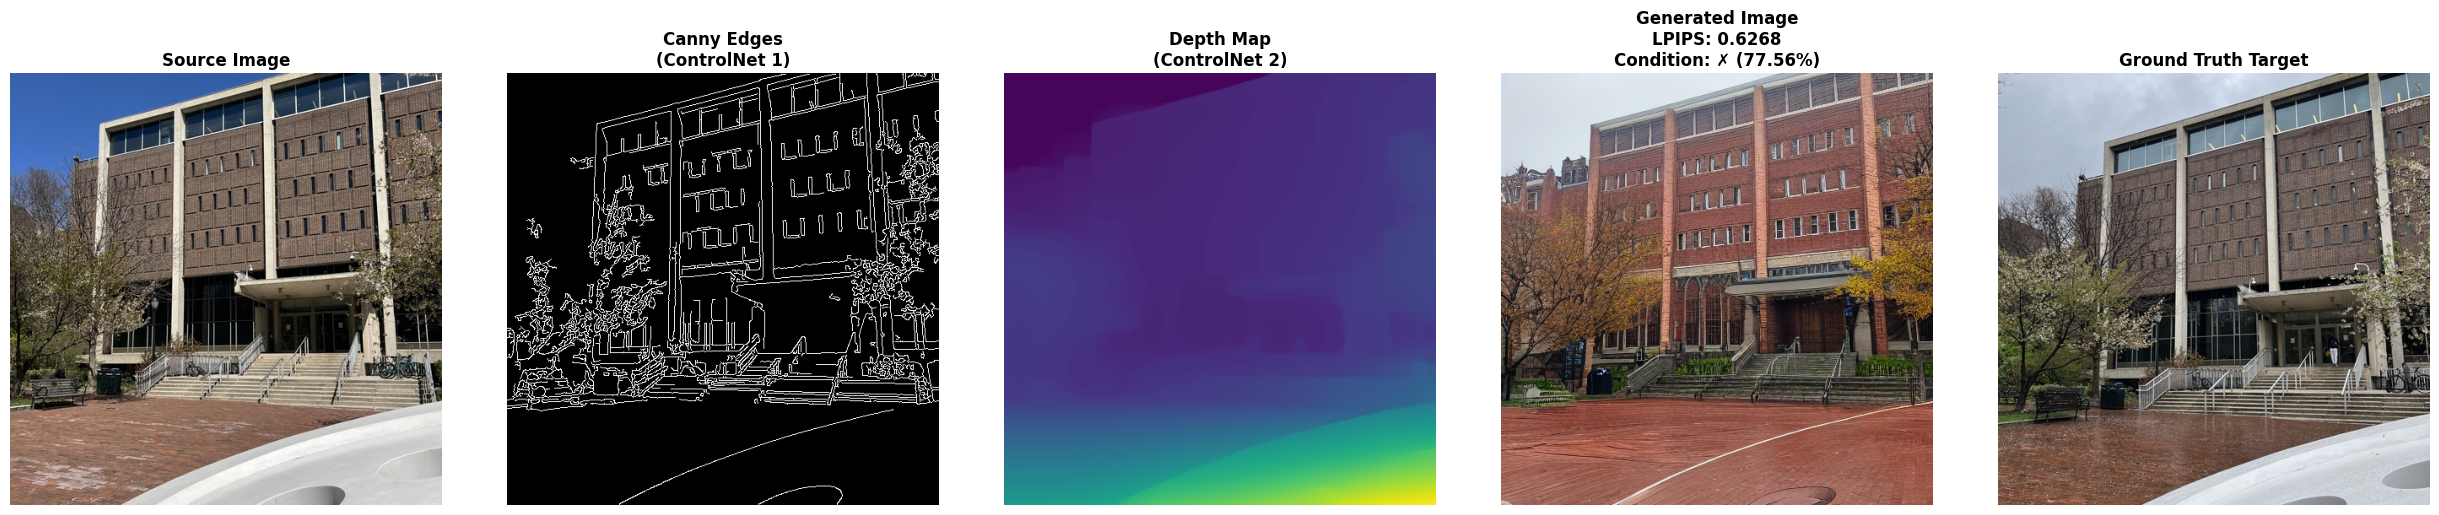

In [38]:
# ========================================================================
# SINGLE IMAGE INFERENCE - Use this for testing
# ========================================================================

# Upload source image
print("Upload source image:")
uploaded = files.upload()
source_filename = list(uploaded.keys())[0]
source_path = f"/content/{source_filename}"

# Enter prompt
print("\nEnter target condition prompt:")
prompt = input("Prompt: ")

# Optional: Upload target image for LPIPS
print("\nDo you have a ground truth target image? (y/n)")
has_target = input().lower().strip() == 'y'

target_image = None
if has_target:
    print("\nUpload target (ground truth) image:")
    target_files = files.upload()
    target_filename = list(target_files.keys())[0]
    target_image = Image.open(f"/content/{target_filename}").convert("RGB")

# Optional: Specify target condition for accuracy
print("\nEnter expected target condition for accuracy metric:")
print("(e.g., 'a photo taken at nighttime in clear weather')")
target_condition_text = input("Target condition: ")

print("\n" + "="*70)
print("STARTING INFERENCE")
print("="*70)


# Generate style transfer
result = generate_style_transfer(
    source_image=source_path,
    prompt=prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    controlnet_conditioning_scale=[0.8, 0.8],  # [canny, depth]
    seed=42
)


# Compute LPIPS (if target provided)
lpips_score = None
if target_image is not None:
    print("\nComputing LPIPS...")
    lpips_score = compute_lpips(result['generated_image'], target_image)
    print(f"LPIPS Score: {lpips_score:.4f}")

# Compute Condition Accuracy
print("\nComputing Condition Accuracy...")
condition_result = compute_condition_accuracy(
    result['generated_image'],
    target_condition_text
)

print(f"\nPredicted Condition: {condition_result['predicted_condition']}")
print(f"Confidence: {condition_result['confidence']:.2%}")
print(f"Correct: {'✓' if condition_result['is_correct'] else '✗'}")



# Visualize
visualize_results(
    result,
    target_image=target_image,
    lpips_score=lpips_score,
    condition_result=condition_result
)

In [26]:
# Print evaluation report
print("\n" + "="*70)
print("EVALUATION REPORT")
print("="*70)

if lpips_score is not None:
    print(f"\n📊 LPIPS (Perceptual Similarity): {lpips_score:.4f}")
    print("   └─ Lower is better (0 = identical)")
    if lpips_score < 0.2:
        print("   └─ ✅ Excellent quality")
    elif lpips_score < 0.35:
        print("   └─ ✅ Good quality")
    elif lpips_score < 0.5:
        print("   └─ ⚠️  Acceptable")
    else:
        print("   └─ ⚠️  Needs improvement")

print(f"\n🎯 Condition Accuracy:")
print(f"   Target: {target_condition_text}")
print(f"   Predicted: {condition_result['predicted_condition']}")
print(f"   Match: {'✓ YES' if condition_result['is_correct'] else '✗ NO'}")
print(f"   Confidence: {condition_result['confidence']:.2%}")

print(f"\n📈 All Condition Probabilities:")
for cond, prob in sorted(condition_result['all_probs'].items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 20)
    print(f"   {cond:50s} {prob:5.1%} {bar}")

print("="*70)


EVALUATION REPORT

📊 LPIPS (Perceptual Similarity): 0.7106
   └─ Lower is better (0 = identical)
   └─ ⚠️  Needs improvement

🎯 Condition Accuracy:
   Target: Vagelos lab in night time in cloudy weather
   Predicted: a photo taken at nighttime in cloudy weather
   Match: ✗ NO
   Confidence: 46.37%

📈 All Condition Probabilities:
   a photo taken at nighttime in cloudy weather       46.4% █████████
   a photo taken at nighttime in rainy weather        29.1% █████
   a photo taken at nighttime in clear weather        21.2% ████
   a photo taken during daytime in rainy weather       1.9% 
   a photo taken during daytime in cloudy weather      1.3% 
   a photo taken during daytime in sunny weather       0.1% 
